# MODELIZACIÓN REGRESION LOSS GIVEN DEFAULT

## IMPORTAR PAQUETES

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV, KFold

from sklearn.metrics import mean_absolute_error

#Autocompletar rápido
%config IPCompleter.greedy=True

#Desactivar la notación científica
pd.options.display.float_format = '{:.2f}'.format

#Desactivar los warnings
import warnings
warnings.filterwarnings("ignore")

## IMPORTAR LOS DATOS

Sustituir la ruta del proyecto.

In [2]:
from credit_scoring.config import PROCESSED_DATA_DIR

ruta_proyecto = PROCESSED_DATA_DIR

2026-09-16 05:18:33.600 | INFO     | credit_scoring.config:<module>:11 - PROJ_ROOT path is: /home/isailzc/credit_scoring/credit_scoring


Nombres de los archivos de datos.

In [3]:
nombre = 'df_tablon_lgd.pickle'

Cargar los datos.

In [4]:
df = pd.read_pickle(ruta_proyecto / nombre)

## CREAR X e Y

In [5]:
x = df.drop(columns='target_lgd')
y = df.target_lgd

## MODELIZAR

### Reservar el dataset de validacion

In [6]:
train_x,val_x,train_y,val_y = train_test_split(x,y,test_size=0.3, random_state=42)

### Crear el pipe y el diccionario de algorimos, parámetros y valores a testar

In [9]:
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

pipe = Pipeline([('algoritmo',Ridge())])

grid = [      
        {'algoritmo': [Ridge()],
         'algoritmo__alpha': list(np.arange(0.1,1.1,0.1))},
        
        {'algoritmo': [Lasso(random_state=42)],
         'algoritmo__alpha': list(np.arange(0.1,1.1,0.1))},
    
        {'algoritmo': [HistGradientBoostingRegressor(min_samples_leaf = 100, random_state=42)],
         'algoritmo__learning_rate': [0.01,0.025,0.05,0.1],
         'algoritmo__max_iter': [50,100,200],
         'algoritmo__max_depth': [5,10,20],
         'algoritmo__l2_regularization': [0,0.25,0.5,0.75,1]}
       ]

### Optimizar los hiper parámetros

####  Con grid search

In [10]:
grid_search = GridSearchCV(estimator= pipe, 
                           param_grid = grid, 
                           cv = cv_strategy, 
                           scoring = 'neg_mean_absolute_error',
                           verbose = 1,
                           n_jobs = -1)

modelo = grid_search.fit(train_x,train_y)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


In [11]:
salida = pd.DataFrame(grid_search.cv_results_).sort_values(by = 'rank_test_score').reset_index(drop=True).head(10)
salida

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algoritmo,param_algoritmo__alpha,param_algoritmo__l2_regularization,param_algoritmo__learning_rate,param_algoritmo__max_depth,param_algoritmo__max_iter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,17.84,1.69,0.83,0.14,HistGradientBoostingRegressor(l2_regularizatio...,NaN,1,0.10,20,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-0.37,-0.37,-0.37,-0.37,-0.38,-0.37,0.00,1
1,17.15,1.86,1.46,0.32,HistGradientBoostingRegressor(l2_regularizatio...,NaN,0.25,0.10,10,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-0.37,-0.37,-0.37,-0.37,-0.38,-0.37,0.00,2
2,17.23,1.40,1.54,0.24,HistGradientBoostingRegressor(l2_regularizatio...,NaN,0,0.10,20,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-0.38,-0.37,-0.37,-0.37,-0.38,-0.37,0.00,3
3,19.75,1.66,1.88,0.46,HistGradientBoostingRegressor(l2_regularizatio...,NaN,1,0.10,10,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-0.38,-0.37,-0.37,-0.37,-0.38,-0.37,0.00,4
4,14.95,0.69,1.11,0.04,HistGradientBoostingRegressor(l2_regularizatio...,NaN,0.75,0.10,20,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-0.37,-0.37,-0.37,-0.37,-0.38,-0.37,0.00,5
5,18.20,2.31,1.37,0.17,HistGradientBoostingRegressor(l2_regularizatio...,NaN,0.25,0.10,20,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-0.37,-0.37,-0.38,-0.37,-0.38,-0.37,0.00,6
6,14.98,0.70,1.18,0.07,HistGradientBoostingRegressor(l2_regularizatio...,NaN,0,0.10,10,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-0.37,-0.37,-0.37,-0.37,-0.38,-0.37,0.00,7
7,14.71,0.50,1.19,0.16,HistGradientBoostingRegressor(l2_regularizatio...,NaN,0.50,0.10,20,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-0.37,-0.37,-0.37,-0.37,-0.38,-0.37,0.00,8
8,13.80,0.75,1.16,0.08,HistGradientBoostingRegressor(l2_regularizatio...,NaN,0.50,0.10,10,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-0.38,-0.38,-0.37,-0.37,-0.38,-0.37,0.00,9
9,14.46,1.20,1.12,0.14,HistGradientBoostingRegressor(l2_regularizatio...,NaN,0.75,0.10,10,200,{'algoritmo': HistGradientBoostingRegressor(l2...,-0.38,-0.37,-0.37,-0.37,-0.38,-0.38,0.00,10


In [21]:
grid_search.best_estimator_

Pipeline(steps=[('algoritmo',
                 HistGradientBoostingRegressor(l2_regularization=1,
                                               max_depth=20, max_iter=200,
                                               min_samples_leaf=100,
                                               random_state=42))])

In [19]:
modelo_lgd = HistGradientBoostingRegressor(learning_rate = 0.1,
                                          max_iter = 200,
                                          max_depth = 20,
                                          min_samples_leaf = 100,
                                          scoring = 'neg_mean_absolute_percentage_error',
                                          l2_regularization = 1,
                                          random_state=42)
modelo_lgd.fit(train_x,train_y)

HistGradientBoostingRegressor(l2_regularization=1, max_depth=20, max_iter=200,
                              min_samples_leaf=100, random_state=42,
                              scoring='neg_mean_absolute_percentage_error')

## EVALUAR

### Predecir sobre validación

In [20]:
pred = modelo_lgd.predict(val_x)

Corregimos los máximos y mínimos.

In [22]:
pred = np.where(pred < 0, 0, pred)
pred = np.where(pred > 1, 1, pred)

### Evaluar sobre validación

In [23]:
mean_absolute_error(val_y, pred)

0.36931422161186045

## REPORTING DEL MODELO

In [24]:
check_validacion = pd.DataFrame({'lgd_real':val_y, 'lgd_pred':pred})
check_validacion

,lgd_real,lgd_pred
id_cliente,,
58390566,1.00,0.46
81563640,1.00,0.39
39672325,0.00,0.26
140399151,1.00,0.69
63074656,0.00,0.43
...,...,...
86216693,0.00,0.48
97487990,1.00,0.41
76254062,0.00,0.59


In [25]:
check_validacion.corr()

,lgd_real,lgd_pred
lgd_real,1.00,0.53
lgd_pred,0.53,1.00


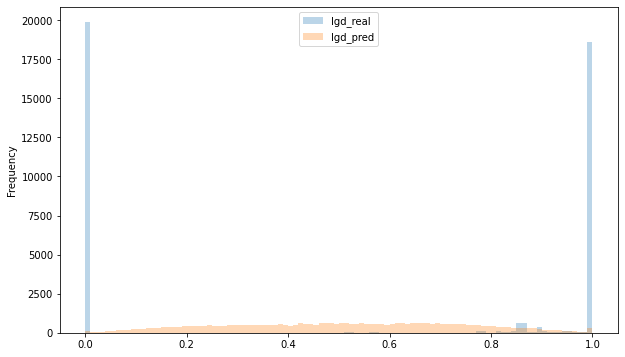

In [26]:
check_validacion.plot.hist(bins = 100,figsize = (10,6), alpha = 0.3);